In [ ]:
#Manual Workflow Dataset Cleaning & Analysis 

#Import Pandas
import pandas as pd
import os

#Import dataframe 
df = pd.read_csv("/Users/saadana/Downloads/manual_workflow.csv")

#Create a copy of the dataframe
df_clean = df.copy()

In [ ]:
#Remove Duplicate Rows

df_clean = df_clean.drop_duplicates(subset='task_id')

In [4]:
#Convert Dates to Standardized Format

df_clean['created_date'] = pd.to_datetime(df_clean['created_date'],errors='coerce')
df_clean['completed_date'] = pd.to_datetime(df_clean['completed_date'],errors='coerce')



In [5]:
#Remove Invalid Dates

df_clean = df_clean.dropna(subset = ['created_date','completed_date'])

In [14]:
#Clean Error Flags 

error_map = {"Y": "Y",
    "Yes": "Y",
    "TRUE": "Y",
    "1": "Y",
    "Error": "Y",
    "N": "N",
    "No": "N",
    "FALSE": "N",
    "0": "N"
}

df_clean['error_flag'] = df_clean['error_flag'].map(error_map).fillna("Unknown")



In [61]:
#Standardize Task Names 

print(sorted(df_clean["task_type"].unique()))

df_clean["task_type"] = (
    df_clean["task_type"]
    .str.strip()
    .str.lower()
)

task_mapping = {
    # Excel Reporting
    "spreadsheet": "Excel Report",
    "excel report": "Excel Report",
    "manual report": "Excel Report",

    # Claims
    "claim": "Claim Review",
    "claim review": "Claim Review",
    "claims review": "Claim Review",

    # Patient Follow-Ups
    "patient follow-up": "Patient Follow-Up",
    "patient followup": "Patient Follow-Up",
    "followup": "Patient Follow-Up",
    "follow-up": "Patient Follow-Up",

    # Lab Follow-Ups
    "lab": "Lab Follow-Up",
    "lab followup": "Lab Follow-Up",
    "lab follow-up": "Lab Follow-Up",
    "diagnostic followup": "Lab Follow-Up",

    # Data Entry
    "data entry": "Data Entry",
    "data-entry": "Data Entry",
    "entry": "Data Entry",
    "manual entry": "Data Entry",

    # Scheduling
    "scheduling": "Scheduling",
    "schedule": "Scheduling",
    "sched": "Scheduling",
    "booking": "Scheduling",
    "billing review": "Billing Review"
}

df_clean["task_type"] = (
    df_clean["task_type"]
    .replace(task_mapping)
)

['Billing Review', 'Claim Review', 'Data Entry', 'Excel Report', 'Lab Follow-Up', 'Patient Follow-Up', 'Scheduling']


In [62]:
#Remove Invalid Manual Minutes

df_clean = df_clean[(df_clean['manual_minutes'] >= 0) & (df_clean['manual_minutes'] <= 720)]


In [63]:
#Create New "Processing Days" Column 

df_clean['processing_days'] = (df_clean['completed_date'] - df_clean['created_date']).dt.days 



In [64]:
from pathlib import Path

downloads_path = Path.home() / "Downloads"
os.chdir(downloads_path)

df_clean.to_csv("manual_workflow_clean.csv", index=False)

In [75]:
#Analysis 

#Minutes Spent on Each Task 
task_time = (df_clean.groupby('task_type')['manual_minutes'].sum().sort_values(ascending = False))

#Top Most Time-Consuming Tasks 
print(task_time)



task_type
Excel Report         8232514.7
Claim Review         4025589.9
Patient Follow-Up    3017198.8
Data Entry           2268435.4
Scheduling           1528978.7
Lab Follow-Up        1252732.4
Billing Review         81471.2
Name: manual_minutes, dtype: float64


In [76]:
print(f"Most Time Consuming Task: {task_time.idxmax()}")

Most Time Consuming Task: Excel Report


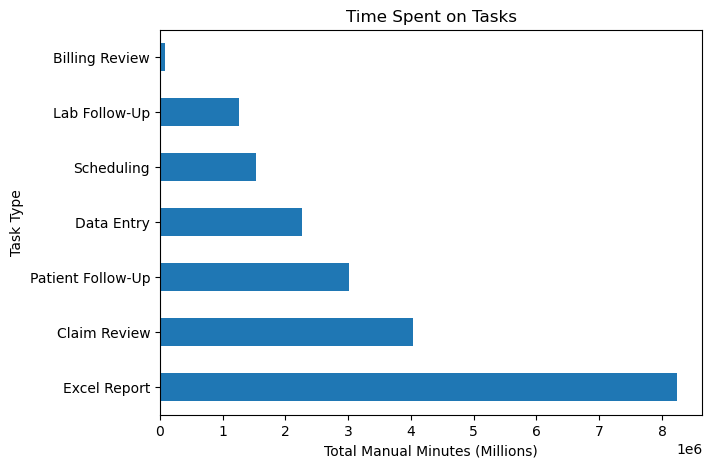

In [141]:
import matplotlib.pyplot as plt

#Create Barplot 

plt.figure(figsize=(7,5))
task_time.plot(kind='barh')

plt.title('Time Spent on Tasks')
plt.xlabel('Total Manual Minutes (Millions)')
plt.ylabel('Task Type')

plt.show()

In [83]:
#Most Common Task Type 
task_frequency = (df_clean['task_type'].value_counts())

#Top Most Common Tasks
print(task_frequency)


task_type
Excel Report         112455
Patient Follow-Up     80436
Claim Review          79336
Data Entry            76505
Scheduling            62455
Lab Follow-Up         36009
Billing Review         1605
Name: count, dtype: int64


In [84]:
#Most Common Task 
print(f"Most Common Task Type: {task_frequency.idxmax()}")

Most Common Task Type: Excel Report


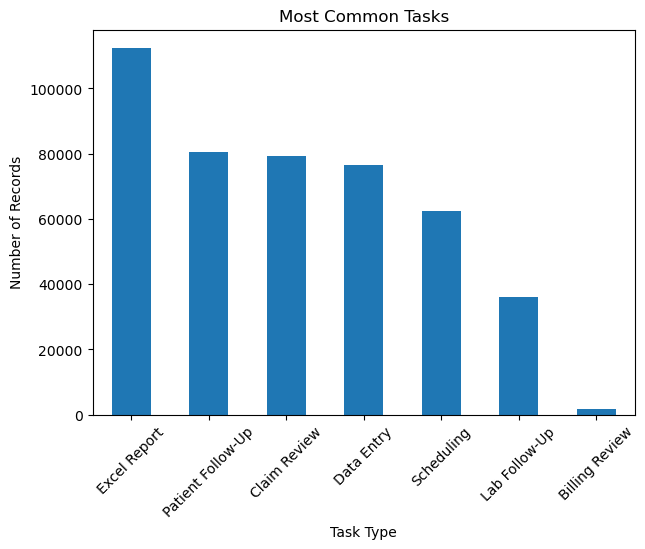

In [86]:
#Create Barplot

plt.figure(figsize=(7,5))
task_frequency.plot(kind='bar')

plt.title("Most Common Tasks")
plt.xlabel("Task Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.show()

In [87]:
#Most Common System Used 
system_frequency = (df_clean['system_used'].value_counts())

#Top Systems Used
print(system_frequency)

system_used
Excel             170305
EMR               134836
Billing System     62776
Email              53860
Paper Form         27024
Name: count, dtype: int64


In [88]:
print(f"Most Used System: {system_frequency.idxmax()}")

Most Used System: Excel


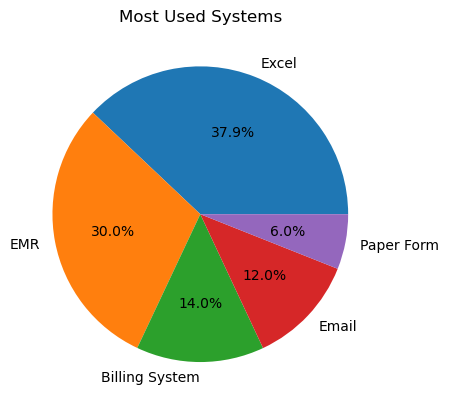

In [89]:
#Create Piechart

plt.pie(system_frequency,labels=system_frequency.index,autopct="%1.1f%%")

plt.title("Most Used Systems")

plt.show()

In [125]:
#Average Time for Task Completion

avg_processing = (df_clean.groupby('task_type')['manual_minutes'].mean().sort_values(ascending=False))
print(avg_processing)

task_type
Excel Report         73.207191
Billing Review       50.760872
Claim Review         50.741024
Patient Follow-Up    37.510552
Lab Follow-Up        34.789425
Data Entry           29.650812
Scheduling           24.481286
Name: manual_minutes, dtype: float64


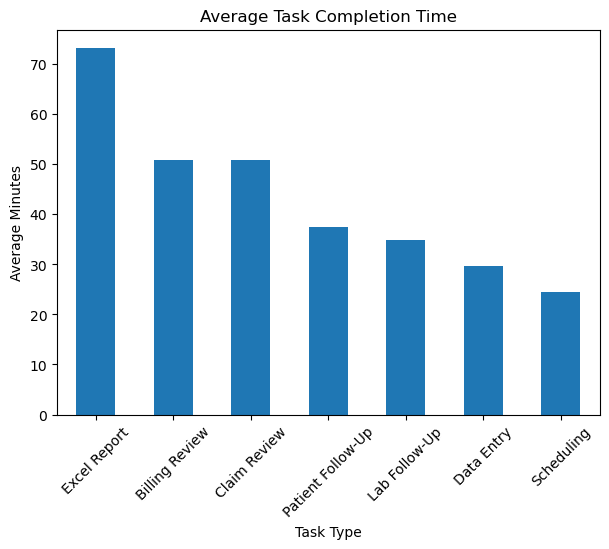

In [128]:
#Bar Chart of Average Minutes to Complete Tasks 
plt.figure(figsize=(7,5))
avg_processing.plot(kind='bar')

plt.title('Average Task Completion Time')
plt.xlabel('Task Type')
plt.ylabel('Average Minutes')

plt.xticks(rotation=45)
plt.show()

In [118]:
#Total Time Consumed By Each System 
system_minutes = (df_clean.groupby('system_used')['manual_minutes'].sum().sort_values(ascending=False))
print(system_minutes)

system_used
Excel             7757278.0
EMR               6110411.3
Billing System    2858810.5
Email             2452692.4
Paper Form        1227728.9
Name: manual_minutes, dtype: float64


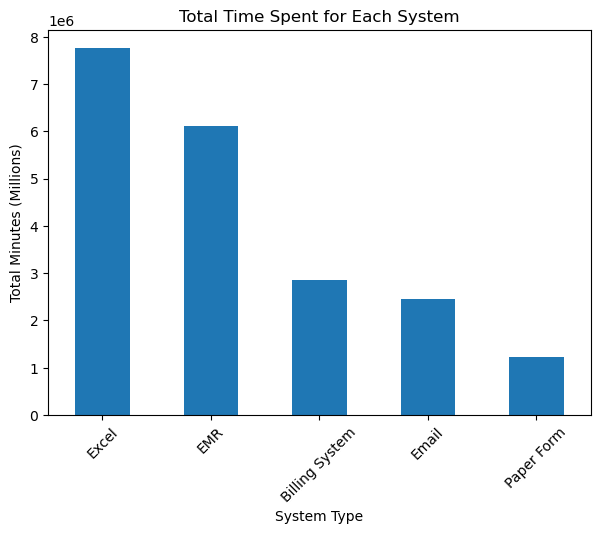

In [132]:
#Visualizing Time Spent on Each System

plt.figure(figsize=(7,5))
system_minutes.plot(kind='bar')

plt.title('Total Time Spent for Each System')
plt.xlabel('System Type')
plt.ylabel('Total Minutes (Millions)')

plt.xticks(rotation=45)
plt.show()

In [133]:
#Processing Days for Each System 

system_processing = (df_clean.groupby("system_used")["processing_days"].mean().sort_values(ascending=False))

print(system_processing)

system_used
EMR               2.282380
Excel             2.278459
Billing System    2.276969
Paper Form        2.275015
Email             2.271055
Name: processing_days, dtype: float64


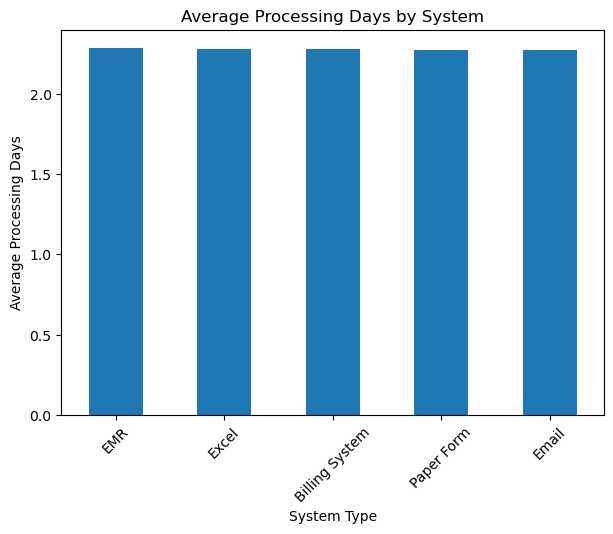

In [134]:
#Visualizing Processing Days for Each System 

plt.figure(figsize=(7,5))

system_processing.plot(kind='bar')

plt.title('Average Processing Days by System')
plt.xlabel('System Type')
plt.ylabel('Average Processing Days')

plt.xticks(rotation=45)
plt.show()

In [139]:
#Create Summary Chart

summary = pd.DataFrame({
    "Task Count":
        df_clean.groupby("task_type").size(),

    "Average Manual Minutes":
        df_clean.groupby("task_type")["manual_minutes"].mean(),

    "Average Processing Days":
        df_clean.groupby("task_type")["processing_days"].mean()
})

summary = summary.sort_values(
    by="Average Manual Minutes",
    ascending=False
)

print(summary.head(10))

                   Task Count  Average Manual Minutes  Average Processing Days
task_type                                                                     
Excel Report           112455               73.207191                 2.729278
Billing Review           1605               50.760872                 2.358879
Claim Review            79336               50.741024                 2.364601
Patient Follow-Up       80436               37.510552                 2.152034
Lab Follow-Up           36009               34.789425                 2.098337
Data Entry              76505               29.650812                 2.022561
Scheduling              62455               24.481286                 1.934465
